<a href="https://colab.research.google.com/github/rlpinhal/Aprendendo_Python/blob/main/aula_22_analise_estatistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #biblioteca de análise de dados
import numpy as np #biblioteca numérica
import matplotlib.pyplot as plt #biblioteca para criar gráficos
import seaborn as sns #biblioteca de funções estatísticas

In [ ]:
#quando usamos o seaborn, que é nossa biblioteca de estatística, podemos usar ela na criação de gráficos
# configurar o visual dos gráficos pelo seaborn
sns.set_theme(style='whitegrid')

#vamos carregar os dados para uso
df_shoes = pd.read_csv('/content/shoes_sales_dataset.csv')

In [ ]:
#Mostra algumas informações como contagem de colunas, tipo de coluna
df_shoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [ ]:
#imprime os valores únicos de determinada coluna que eu selecionei, no caso Color
print(df_shoes['Color'].unique())

['Blue' 'Grey' 'White' 'Green' 'Red' 'Black']


In [ ]:
#função que descreve de forma resumida os valores estatísticos dos dados numéricos da tabela
df_shoes.describe().style.format("{:.2f}")

,Price_USD,Units_Sold,Revenue_USD
count,1000.00,1000.00,1000.00
mean,137.86,10.58,1453.19
std,64.27,5.84,1112.33
min,31.02,1.00,32.38
25%,81.91,6.00,561.05
50%,139.29,10.00,1132.62
75%,193.75,16.00,2163.35
max,249.94,20.00,4938.40


In [ ]:
#bloco de funções

#função 1 - ver_dados
def ver_dados():
# o usuário escolhe quantos dados ele quer ver, seja 1 ou todos
  resposta = int(input('Informe quantas linhas de dados você quer ver: '))
  df_shoes.head(resposta)
  return df_shoes.head(resposta)

#função 2 - medidas de tendência
#média - moda - mediana

def medidas_tendencia():
  #para as medidas de tendencia, temos funções prontas para cada uma delas
  #mean() - média
  #median() - mediana
  #mode()[0] - moda
  media_precos = df_shoes['Price_USD'].mean()
  media_qtd_produtos = df_shoes['Units_Sold'].mean()
  media_total_vendas = df_shoes['Revenue_USD'].mean()

  #calculos de moda
  moda_cor_primeiro = df_shoes['Color'].mode()[0]
  moda_marca = df_shoes['Brand'].mode()[0]

  #calculo de mediana
  mediana_precos = df_shoes['Price_USD'].median()
  mediana_qtd_produtos=df_shoes['Units_Sold'].median()

  #calculo do desvio padrao
  desvio_coluna = df_shoes['Price_USD'].std()

  #imprimir as informações obtidas
  return (print(f'A média de preços foi de {media_precos:.2f}\n'
  f'A quantidade média de produtos vendidos foi de {media_qtd_produtos:.2f}\n'
  f'A média do total de vendas foi de {media_total_vendas:.2f}\n'
  f'O produto com a maior moda é {moda_cor_primeiro}\n'
  f'A marca com a maior moda é {moda_marca}\n'
  f'A mediana dos preços é {mediana_precos}\n'
  f'A mediana da quantidade de produtos é {mediana_qtd_produtos}\n'
  f'O desvio padrão do preço é {desvio_coluna:.2f}\n'
  ))

def dispersao_variabilidade():
  plt.figure(figsize=(8,5))
  #para tratarmos o tamanho da img
  #o matplotlib, de maneira simples ou fácil, não faz boxplot, mas o seaborn faz
  sns.boxplot(x=df_shoes['Revenue_USD'],color='skyblue')

  #para dar um título
  plt.title('Distribuição da Receita')

def histograma():
  plt.figure(figsize=(8,5))
  sns.histplot(df_shoes['Price_USD'], kde=True, color = 'red',bins=10)

def dispersao():
#precisamos de dois pontos para analise
  plt.figure(figsize=(8,5))
  sns.scatterplot(data=df_shoes, x='Price_USD',y='Revenue_USD')

def pizza():
  #1 - preparar
  dados_pizza = df_shoes['Sales_Channel'].value_counts()
  # le dado por dado e mostra suas quantidades

  # 2 - escolher o layout de cores para os setores (cor de cada fatia)
  cores =sns.color_palette('pastel')

  # 3 - criar o gráfico
  plt.figure(figsize=(8,5))
  #plt.pie(os dados, autopct='casas decimais,startangle = angulo de início, color)
  plt.pie(dados_pizza,
          labels=dados_pizza.index,
          autopct='%1.1f%%',
          startangle=140,
          colors=cores)

In [ ]:
medidas_tendencia()

A média de preços foi de 137.86
A quantidade média de produtos vendidos foi de 10.58
A média do total de vendas foi de 1453.19
O produto com a maior moda é Grey
A marca com a maior moda é Skechers
A mediana dos preços é 139.295
A mediana da quantidade de produtos é 10.0
O desvio padrão do preço é 64.27



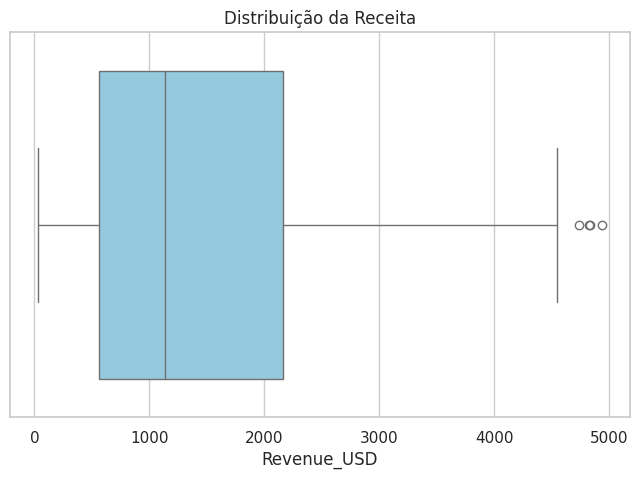

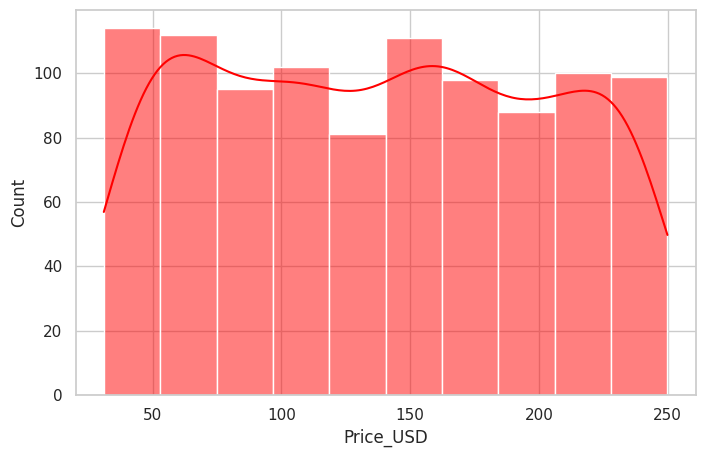

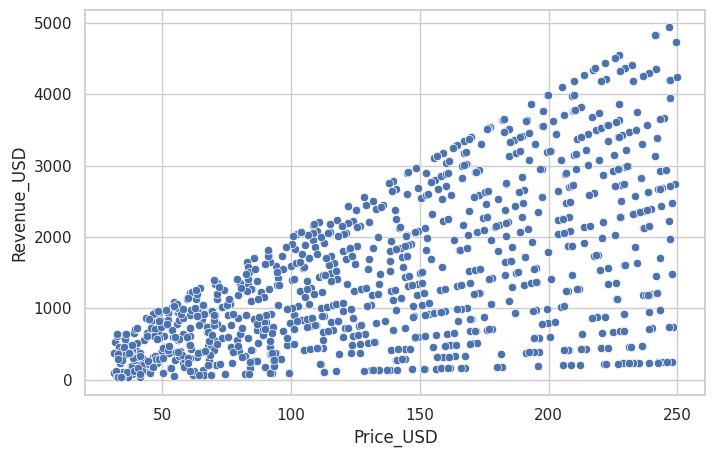

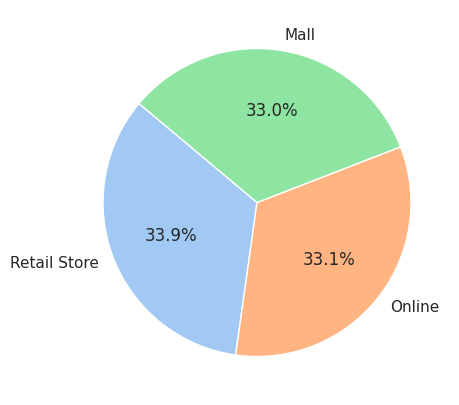

In [ ]:
dispersao_variabilidade()
histograma()
dispersao()
pizza()